<a href="https://colab.research.google.com/github/jose-luis-hernandez-amaya/Simulaci-n-1/blob/main/TIBASA_ejercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIBASA
La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?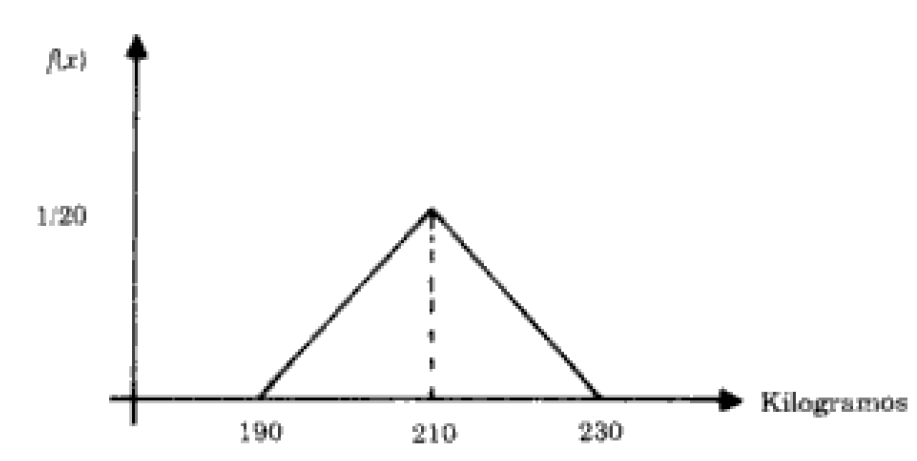

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy.stats as st

Se utilizara una distribucion inversa triangular, como se ve en la imagen anterior

In [10]:
def simular_peso_tina():
    u = random.uniform(0, 1)
    if u < 0.5:
        # Lado izquierdo del triángulo
        return 190 + np.sqrt(800 * u)
    else:
        # Lado derecho del triángulo
        return 230 - np.sqrt(800 * (1 - u))

Utilizaremos solo **1 variable** que será la suma del peso de las 5 tinas

In [11]:
def viaje_excede_capacidad():
    peso_total = sum(simular_peso_tina() for _ in range(5))

    # Retorna 1 si el camión excede la tonelada (1000 kg), 0 si está seguro
    if peso_total > 1000:
        return 1
    else:
        return 0

In [12]:
def experimento_tibasa(iteraciones):
    i = 1
    viajes_excedidos = 0
    lista_probabilidades = []

    while i <= iteraciones:
        viajes_excedidos += viaje_excede_capacidad()
        prob_actual = viajes_excedidos / i
        lista_probabilidades.append(prob_actual)
        i += 1

    return lista_probabilidades

In [13]:
exp = experimento_tibasa(100000) #Con 100,000 se ve bien la gráfica

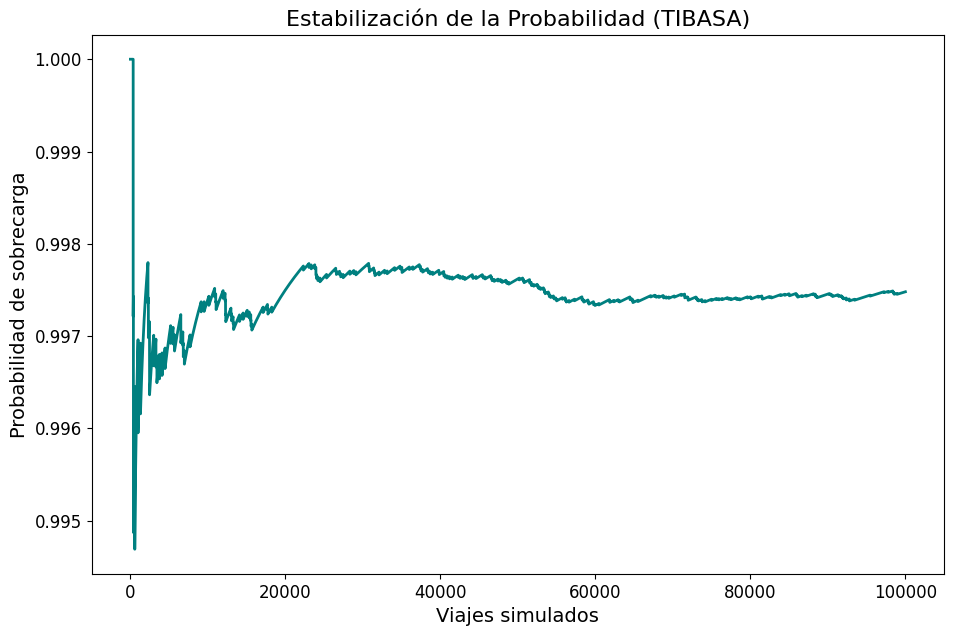

In [14]:
plt.figure(figsize=(11, 7), dpi=100)
plt.plot(exp, color='teal', linewidth=2)
plt.xlabel('Viajes simulados', fontsize=14)
plt.ylabel('Probabilidad de sobrecarga', fontsize=14)
plt.title('Estabilización de la Probabilidad (TIBASA)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [15]:
def simulacion_replicas_tibasa(repeticiones):
    lista_medias = []
    for _ in range(repeticiones):
        # Tomamos la probabilidad estabilizada final de 500 viajes
        promedio_final = experimento_tibasa(500)[-1]
        lista_medias.append(promedio_final)
    return lista_medias

In [16]:
simulacion = simulacion_replicas_tibasa(500)

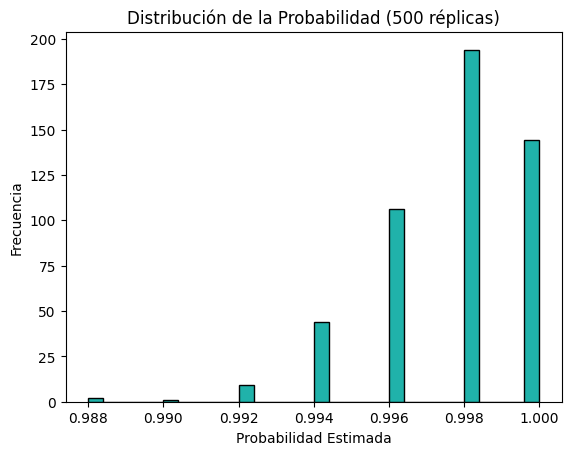

In [17]:
plt.hist(simulacion, bins=30, color='lightseagreen', edgecolor='black')
plt.xlabel('Probabilidad Estimada')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Probabilidad (500 réplicas)')
plt.show()

In [18]:
#Cálculo del intervalo de confianza
mean_simulacion = np.mean(simulacion)
std_simulacion = np.std(simulacion)
n = len(simulacion)
standard_error = std_simulacion / np.sqrt(n)

confidence_interval = st.norm.interval(confidence=0.95, loc=mean_simulacion, scale=standard_error)

print(f"Probabilidad promedio de sobrecargar el camión: {mean_simulacion:.4f} (aprox {mean_simulacion*100:.2f}%)")
print(f"Desviación estándar de las simulaciones: {std_simulacion:.4f}")
print(f"Intervalo de confianza del 95%: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")


Probabilidad promedio de sobrecargar el camión: 0.9976 (aprox 99.76%)
Desviación estándar de las simulaciones: 0.0021
Intervalo de confianza del 95%: (0.9975, 0.9978)
